In [1]:
import random

import numpy as np
from matplotlib import pyplot as plt    

import optax
import equinox as eqx 
from jax import Array, numpy as jnp, random as jr, nn, lax

from qwen import QwenModel, utils, forward

In [2]:
def load_dataset():
    loaded_data = np.load("data.npz")

    obs = loaded_data["obs"][..., :2]
    actions = loaded_data["actions"]
    rewards = loaded_data["rewards"]

    obs_mean, obs_std = obs.mean(axis=0), obs.std(axis=0) + 1e-8
    obs = (obs - obs_mean) / obs_std

    actions = nn.one_hot(actions, num_classes=3)
    rewards = nn.one_hot(rewards + 1, num_classes=3)

    N = obs.shape[0]
    split = int(0.8 * N)

    train_obs, test_obs = obs[:split], obs[split:]
    train_actions, test_actions = actions[:split], actions[split:]
    train_rewards, test_rewards = rewards[:split], rewards[split:]

    return train_obs, train_actions, train_rewards, test_obs, test_actions, test_rewards


def create_batches(obs, actions, rewards, seq_len, batch_size):
    T = obs.shape[0]  

    indices = np.arange(T - seq_len)
    np.random.shuffle(indices)

    batches = []
    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i : i + batch_size]
        
        obs_batch = jnp.stack([obs[idx : idx + seq_len] for idx in batch_indices])
        actions_batch = jnp.stack([actions[idx : idx + seq_len] for idx in batch_indices])
        rewards_batch = jnp.stack([rewards[idx : idx + seq_len] for idx in batch_indices])

        batches.append((obs_batch, actions_batch, rewards_batch))

    return batches

In [3]:
def preprocess(obs, actions):
    B, T, K, D = obs.shape
    obs_flat = jnp.reshape(obs, (B, T, K * D))
    return jnp.concatenate([obs_flat, actions], axis=-1)


def postprocess(out):
    B, T, D = out.shape
    obs, rewards = out[:, :, :-3], out[:, :, -3:]
    return jnp.reshape(obs, (B, T, 3, 2)), rewards


def train(
    key,
    model,
    optimizer,
    train_obs,
    train_actions,
    train_rewards,
    seq_len,
    batch_size,
    epochs,
    eval_callback=None,
    noise_std=0.1,
):
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    def loss_fn(model, prev_obs, prev_actions, next_obs, next_rewards, key):
        inputs = preprocess(prev_obs, prev_actions)
        outputs = forward(model, inputs, key=key, inference=False)
        pred_next_obs, pred_next_rewards = postprocess(outputs)

        obs_loss = jnp.mean((pred_next_obs - next_obs) ** 2)
        reward_loss = jnp.mean((pred_next_rewards - next_rewards) ** 2)
        return obs_loss + reward_loss

    @eqx.filter_jit
    def step(key, model, opt_state, prev_obs, prev_actions, next_obs, next_rewards):
        loss_value, grads = eqx.filter_value_and_grad(loss_fn)(
            model, prev_obs, prev_actions, next_obs, next_rewards, key
        )
        updates, opt_state = optimizer.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    train_batches = create_batches(
        train_obs, train_actions, train_rewards, seq_len, batch_size
    )

    for epoch in range(epochs):
        for batch_idx, (obs_batch, actions_batch, rewards_batch) in enumerate(
            train_batches
        ):
            prev_obs, next_obs = obs_batch[:, :-1], obs_batch[:, 1:]
            prev_act, next_rew = actions_batch[:, :-1], rewards_batch[:, 1:]

            key, subkey1, subkey2, subkey3 = jr.split(key, 4)
            prev_obs_noisy = prev_obs + noise_std * jr.normal(
                subkey1, shape=prev_obs.shape
            )
            next_obs_noisy = next_obs + noise_std * jr.normal(
                subkey2, shape=next_obs.shape
            )

            model, opt_state, loss_value = step(
                subkey3,
                model,
                opt_state,
                prev_obs_noisy,
                prev_act,
                next_obs_noisy,
                next_rew,
            )

        if eval_callback is not None:
            key, subkey = jr.split(key)
            eval_callback(subkey, model, epoch, loss_value)

    return model

In [4]:
@eqx.filter_jit
def generate(key, model, obs_context, actions, max_tokens, context_len):
    generated_obs = []
    generated_rewards = []
    current_obs = obs_context
    for i in range(max_tokens):
        key, subkey = jr.split(key)
        context_obs = current_obs[-context_len:]
        in_obs = context_obs[None, ...]
        L = in_obs.shape[1]
        in_act = actions[i : i + L][None, ...]
        x = preprocess(in_obs, in_act)
        y = forward(model, x, key=subkey, inference=True)
        last_out = y[:, -1:, :]
        pred_obs, pred_rew = postprocess(last_out)
        generated_obs.append(pred_obs[0, 0])
        generated_rewards.append(pred_rew[0, 0])
        current_obs = jnp.concatenate([current_obs, pred_obs[0, 0:1]], axis=0)
    return jnp.stack(generated_obs, axis=0), jnp.stack(generated_rewards, axis=0)


def evaluate(key, model, test_obs, test_actions, test_rewards, context_len, max_tokens):
    start_idx = random.randint(0, test_obs.shape[0] - context_len - max_tokens)
    obs_context = test_obs[start_idx : start_idx + context_len]
    actions_seq = test_actions[start_idx : start_idx + context_len + max_tokens]

    true_obs = test_obs[start_idx + context_len : start_idx + context_len + max_tokens]
    true_rewards = test_rewards[
        start_idx + context_len : start_idx + context_len + max_tokens
    ]

    pred_obs, pred_rewards = generate(
        key, model, obs_context, actions_seq, max_tokens, context_len
    )

    fig, axes = plt.subplots(4, 2, figsize=(8, 8))

    for i in range(3):
        for j in range(2):
            axes[i, j].plot(pred_obs[:, i, j], color="red", label="Pred")
            axes[i, j].plot(true_obs[:, i, j], color="blue", label="True")
            axes[i, j].tick_params(axis="both", which="both", length=0)
            for spine in axes[i, j].spines.values():
                spine.set_linewidth(1.5)

    pred_rewards = jnp.argmax(pred_rewards, axis=-1)
    true_rewards = jnp.argmax(true_rewards, axis=-1)
    axes[3, 0].plot(pred_rewards, color="red", label="Pred")
    axes[3, 0].plot(true_rewards, color="blue", label="True")
    axes[3, 0].tick_params(axis="both", which="both", length=0)
    for spine in axes[3, 0].spines.values():
        spine.set_linewidth(1.5)

    axes[3, 1].plot([0, max_tokens], [0, 0], color="red", linestyle="--", label="Pred")
    axes[3, 1].plot([0, max_tokens], [0, 0], color="blue", linestyle="--", label="True")
    axes[3, 1].legend(loc="center", frameon=False)

    plt.tight_layout()
    plt.show()


forward_jit = eqx.filter_jit(forward)

def evaluate_test(
    key, model, test_obs, test_actions, test_rewards, seq_len, batch_size
):
    test_batches = create_batches(
        test_obs, test_actions, test_rewards, seq_len, batch_size
    )

    total_correct = 0
    total_count = 0
    total_mse = 0.0

    for obs_batch, actions_batch, rewards_batch in test_batches:
        prev_obs, next_obs = obs_batch[:, :-1], obs_batch[:, 1:]
        prev_act, next_rew = actions_batch[:, :-1], rewards_batch[:, 1:]

        inputs = preprocess(prev_obs, prev_act)
        outputs = forward_jit(model, inputs, key=key, inference=True)
        pred_next_obs, pred_next_rewards = postprocess(outputs)

        pred_rew_class = jnp.argmax(pred_next_rewards, axis=-1)
        true_rew_class = jnp.argmax(next_rew, axis=-1)

        correct = jnp.sum(pred_rew_class == true_rew_class)
        total_correct += correct
        total_count += pred_rew_class.size

        mse = jnp.mean((pred_next_obs - next_obs) ** 2)
        total_mse += mse * pred_next_obs.size

    accuracy = total_correct / total_count
    mse_loss = total_mse / total_count

    return float(accuracy), float(mse_loss)

Epoch 0: 4.4431304931640625


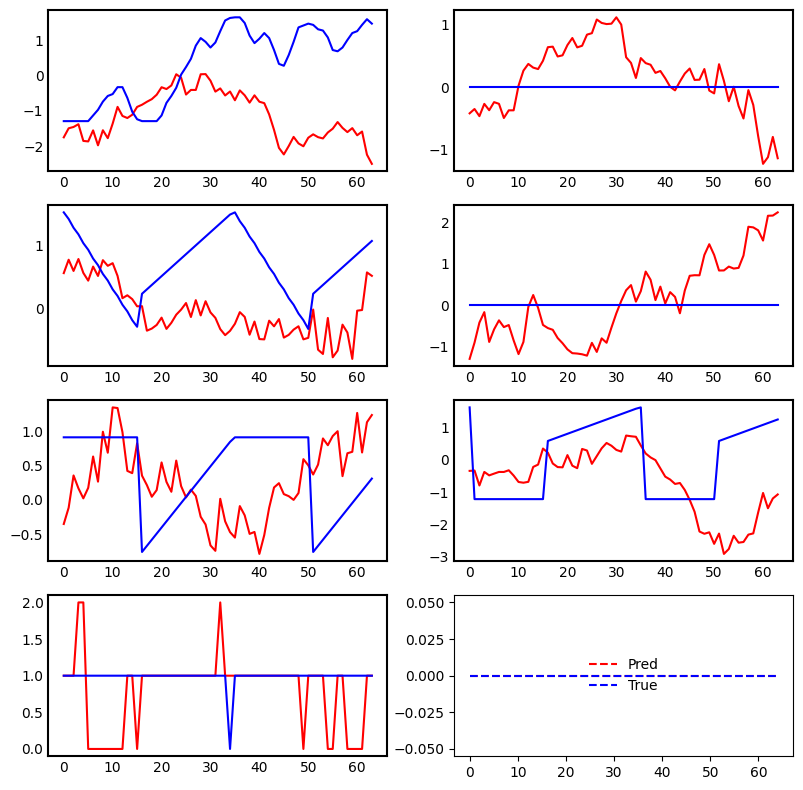

Epoch 50: 0.14481477439403534


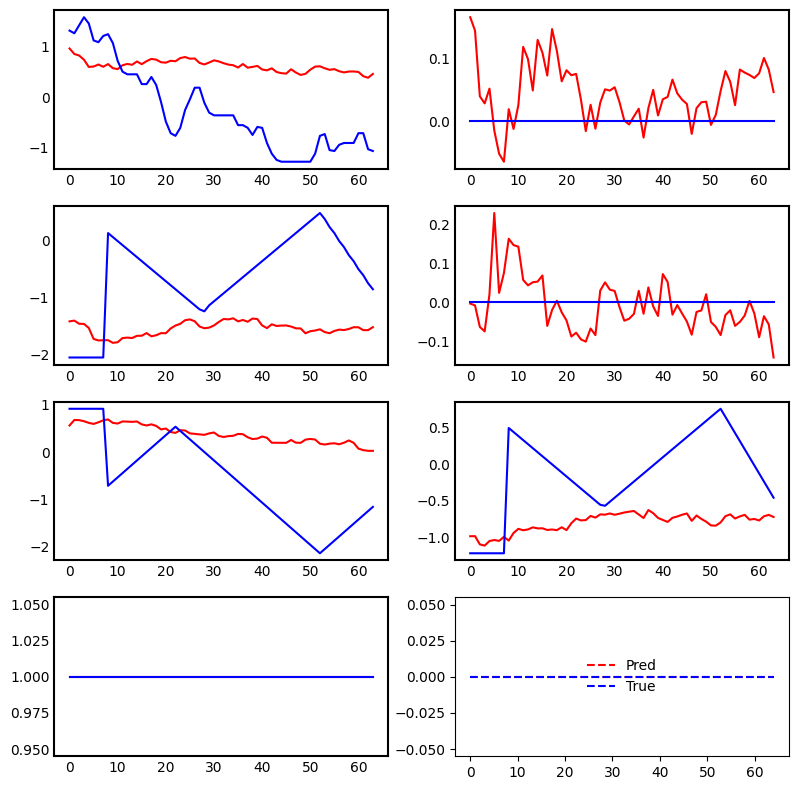

Epoch 100: 0.0883767232298851


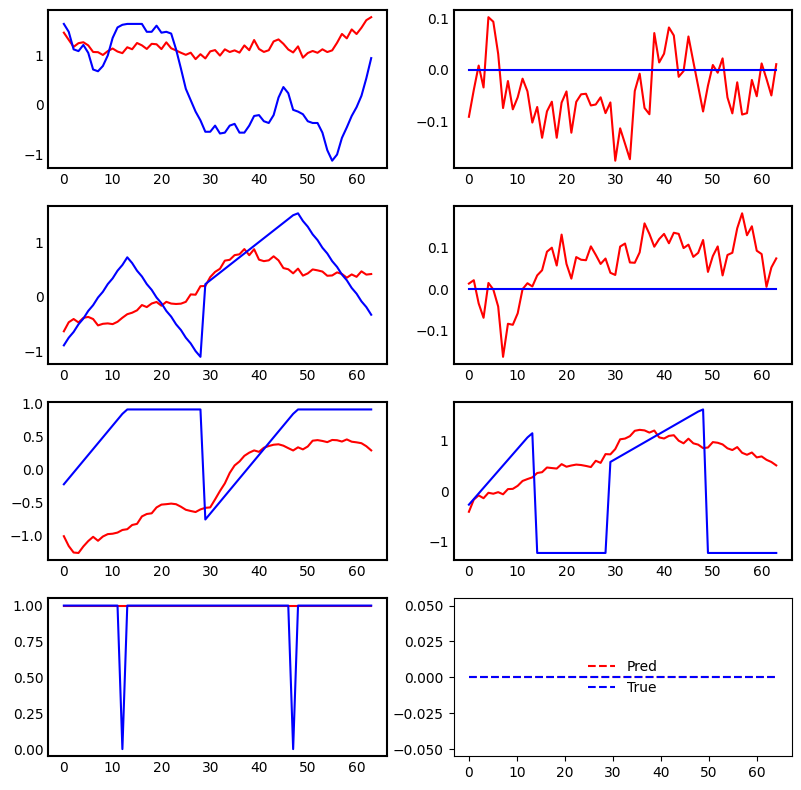

Epoch 150: 0.07744967192411423


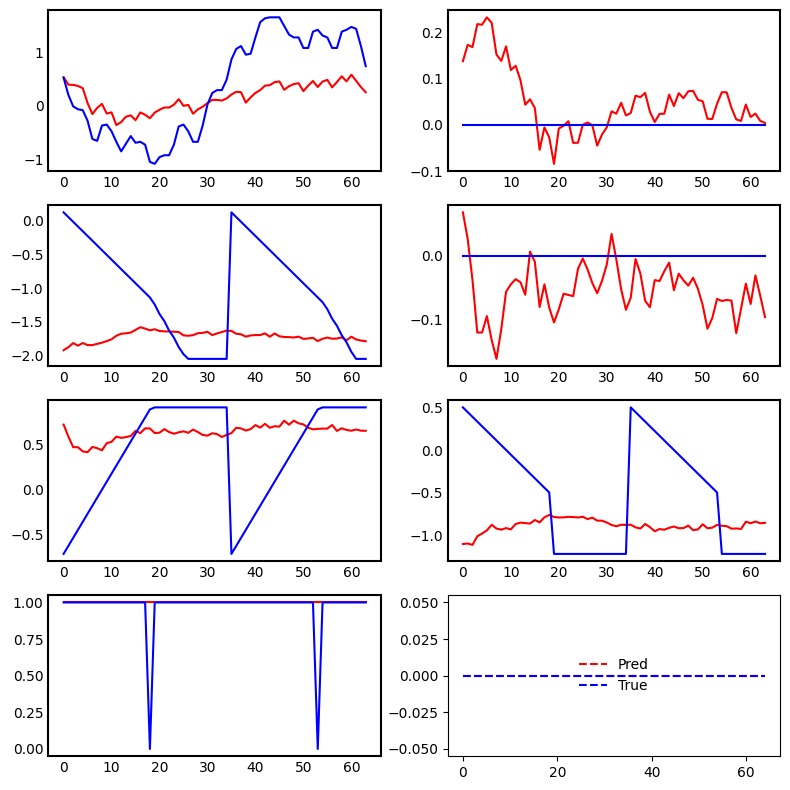

Epoch 200: 0.073320671916008


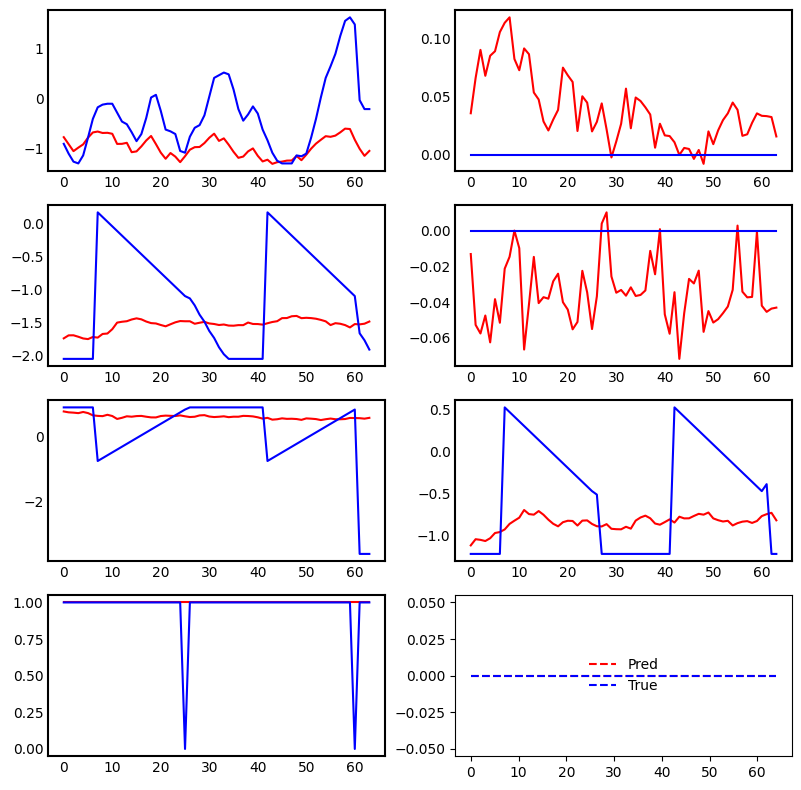

Epoch 250: 0.06449521332979202


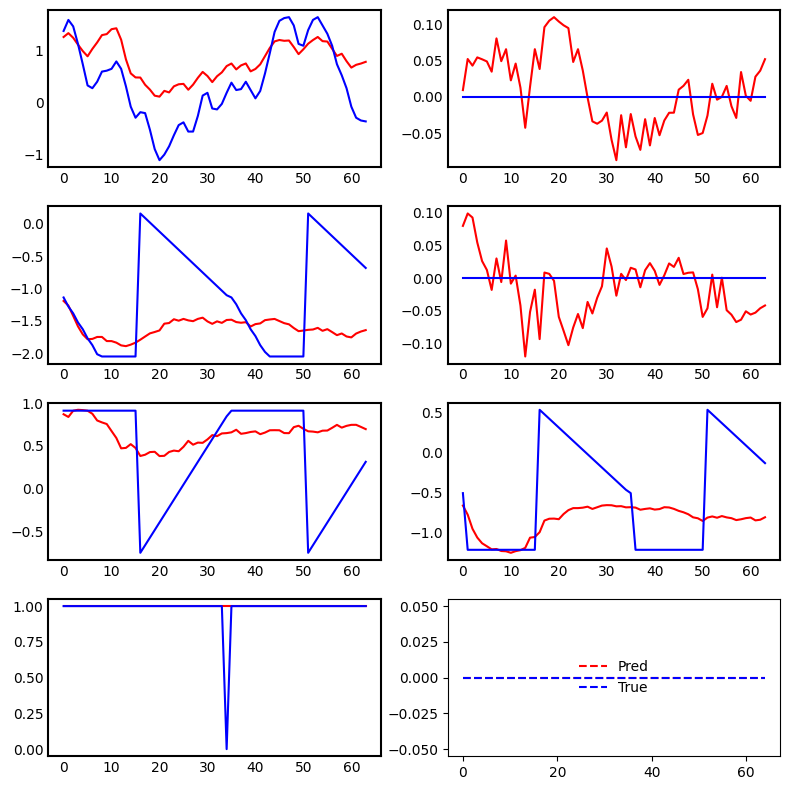

Epoch 300: 0.06099480018019676


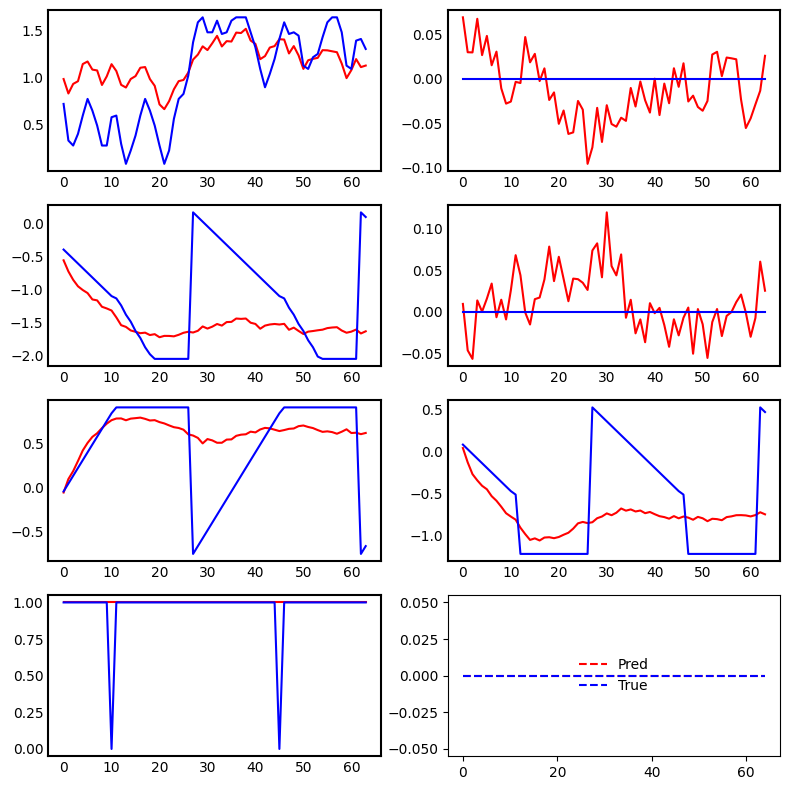

Epoch 350: 0.06034441664814949


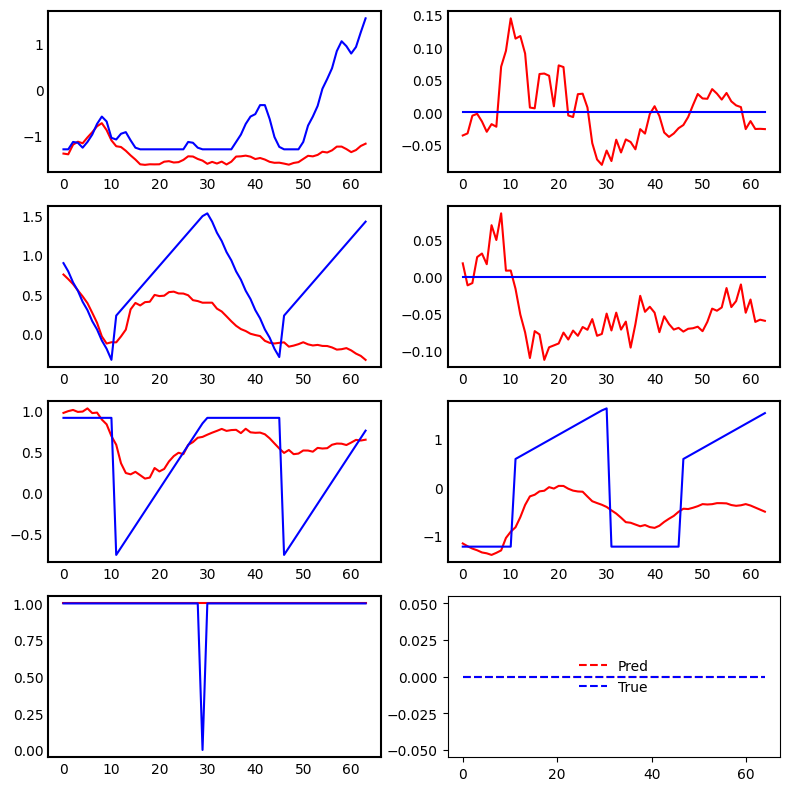

Epoch 400: 0.056974299252033234


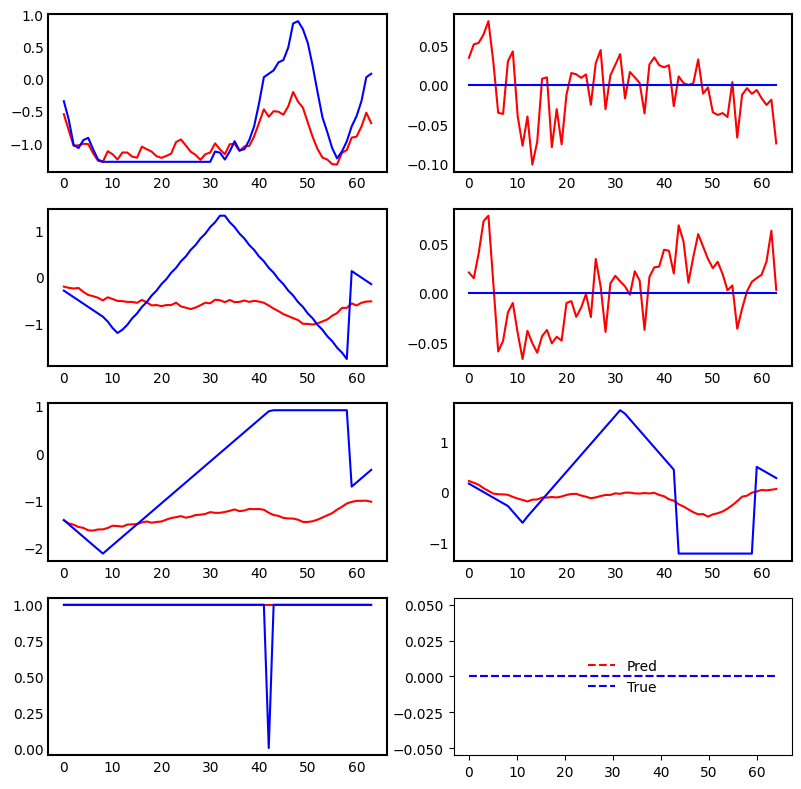

Epoch 450: 0.05999279022216797


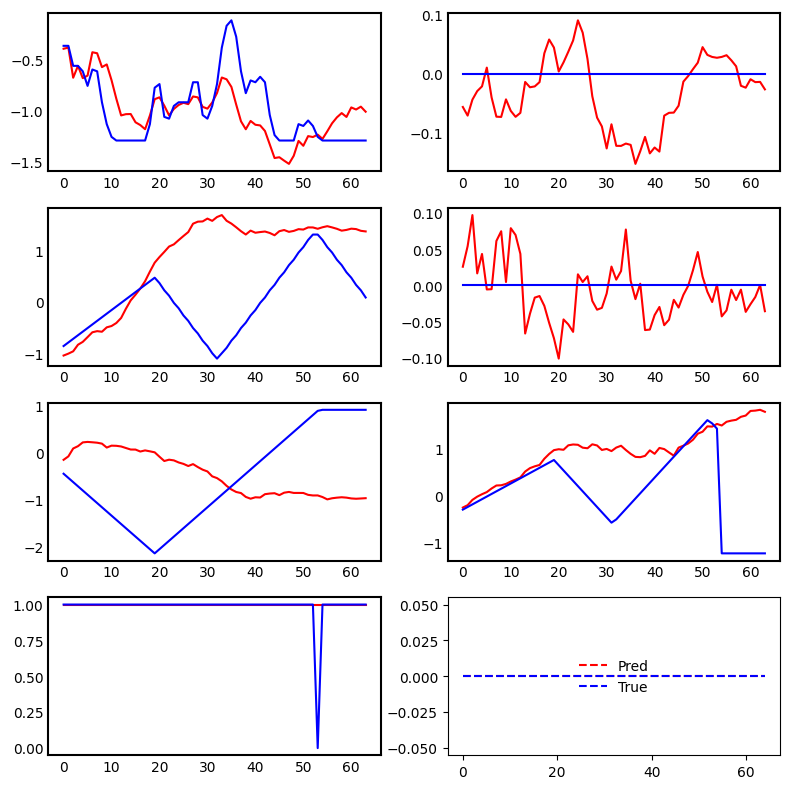

Epoch 500: 0.05788782238960266


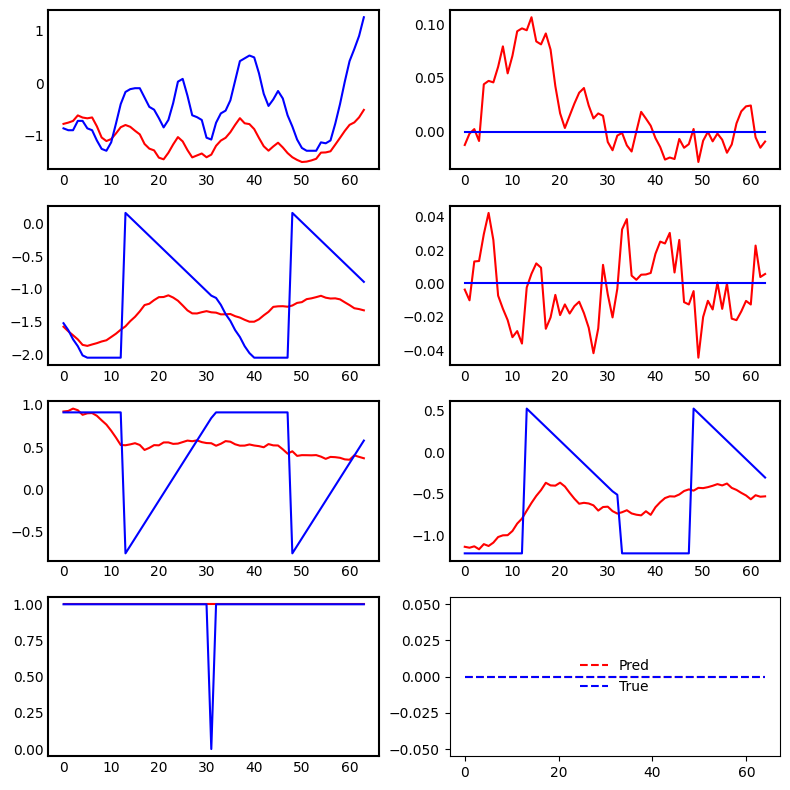

Epoch 550: 0.05888419970870018


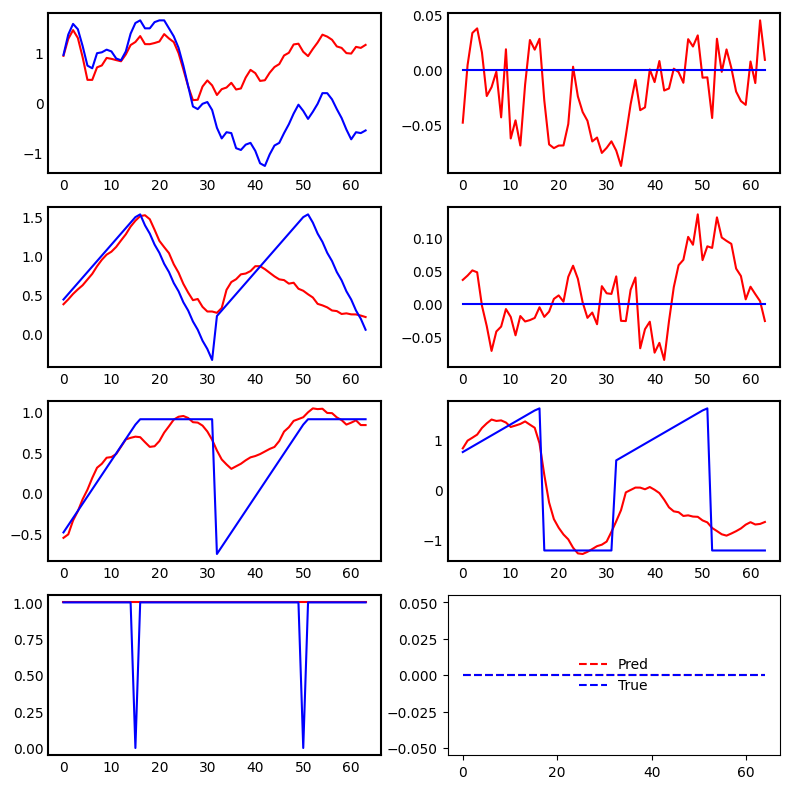

Epoch 600: 0.05778536573052406


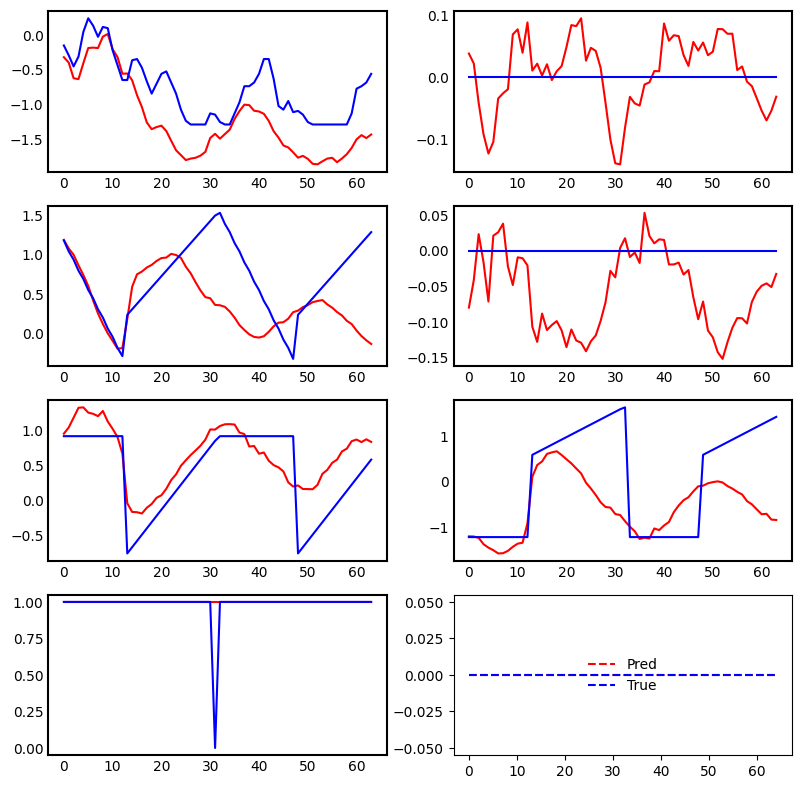

Epoch 650: 0.04295032098889351


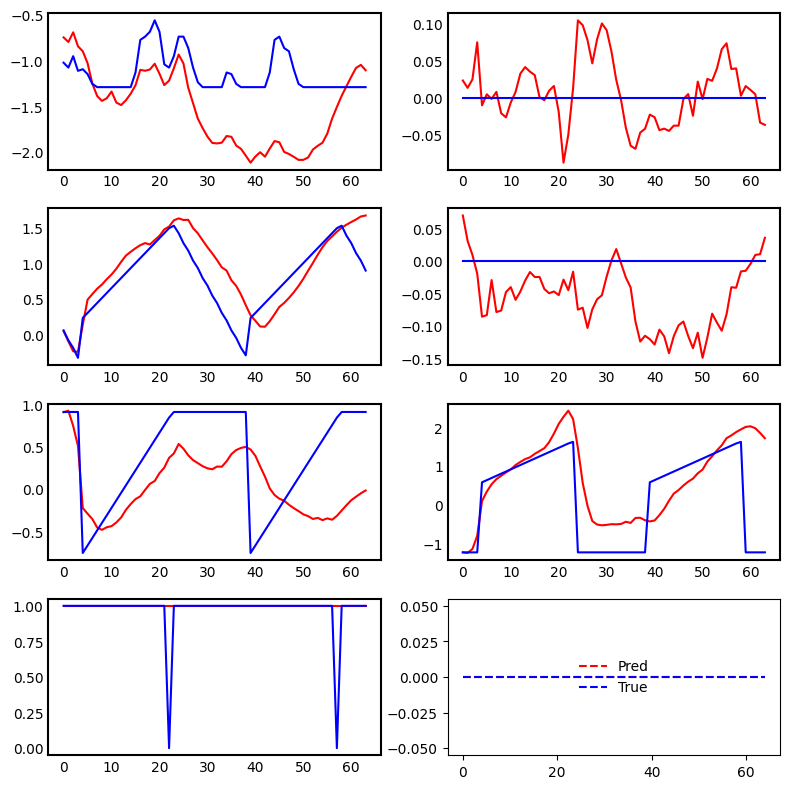

Epoch 700: 0.048183269798755646


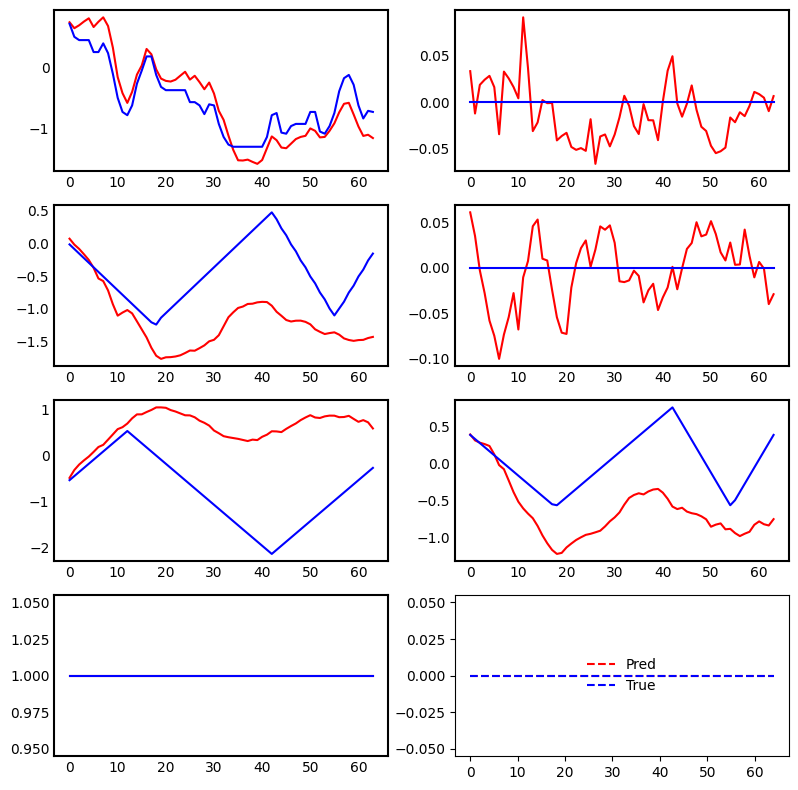

Epoch 750: 0.04083383455872536


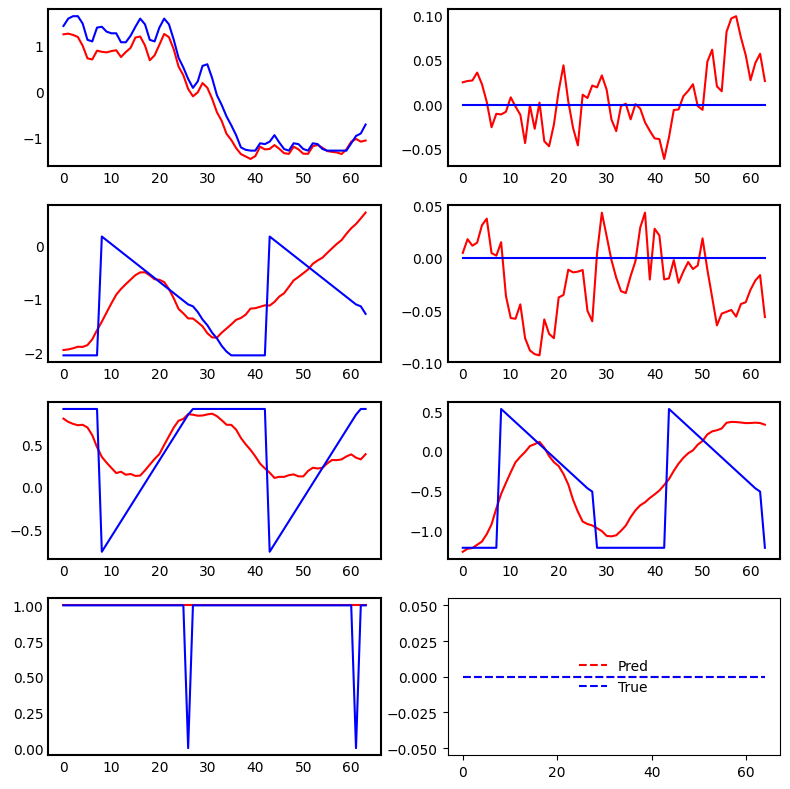

Epoch 800: 0.04111451283097267


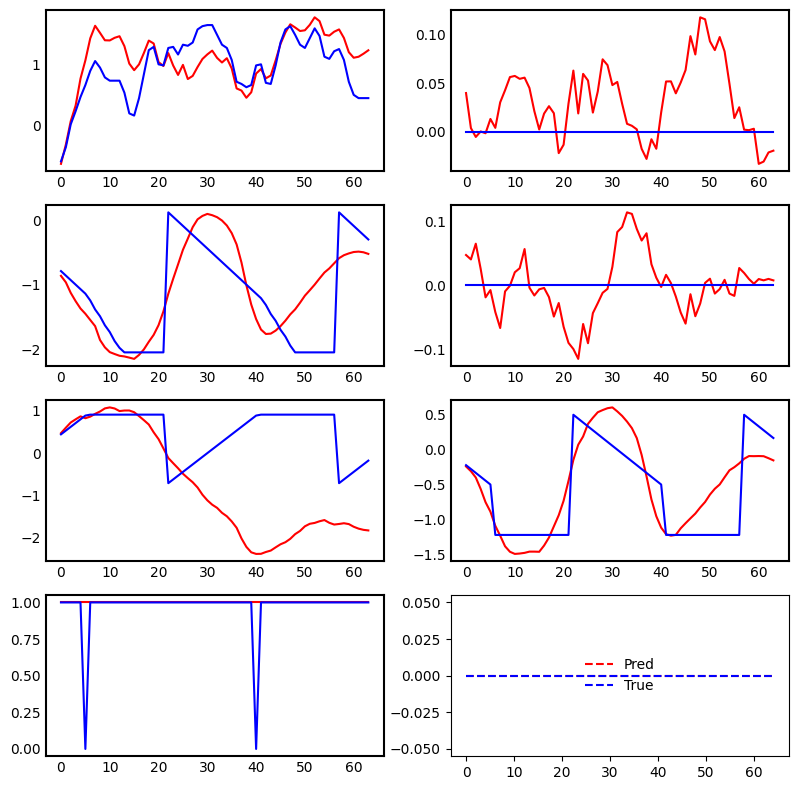

Epoch 850: 0.03898824006319046


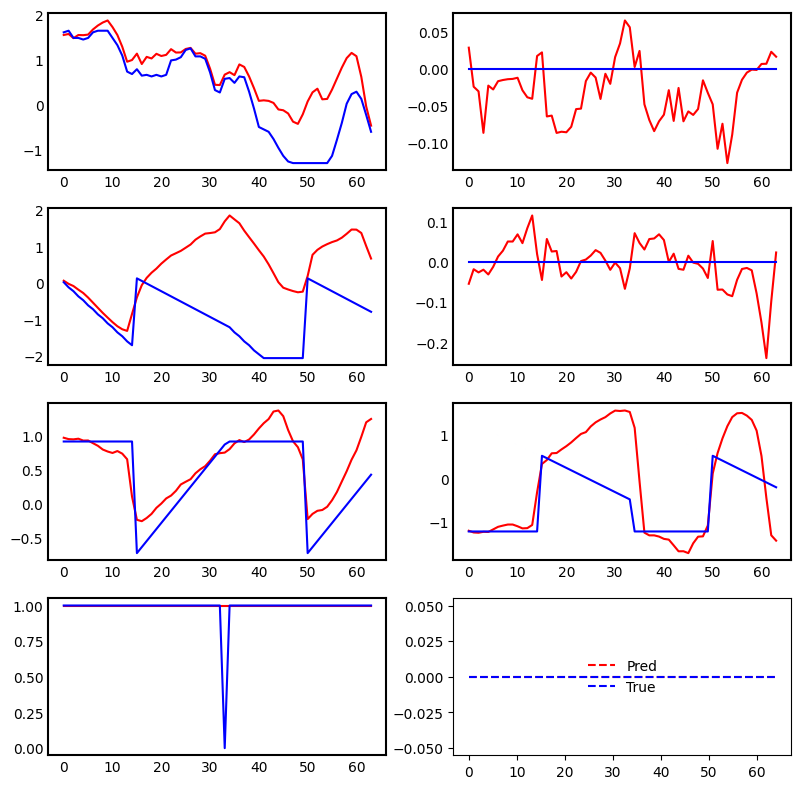

Epoch 900: 0.03405194357037544


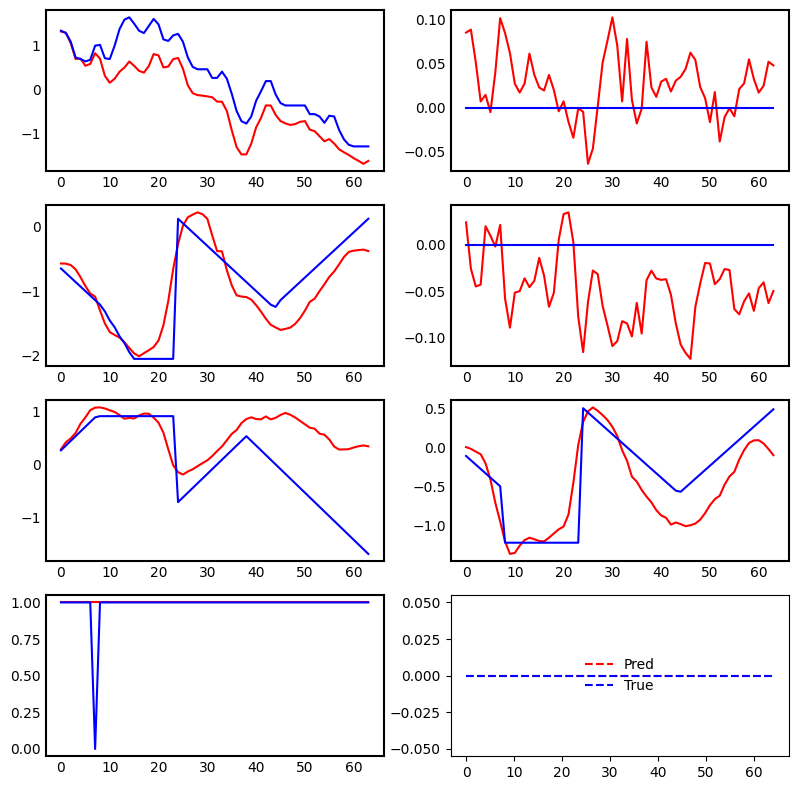

Epoch 950: 0.03744512051343918


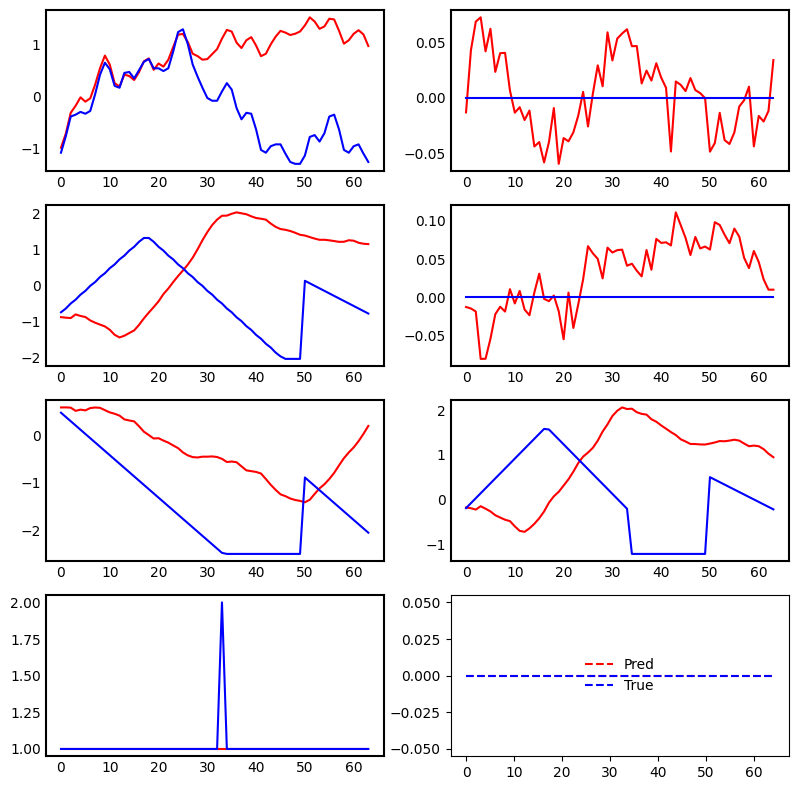

KeyboardInterrupt: 

In [5]:
key = jr.PRNGKey(0)
train_obs, train_actions, train_rewards, test_obs, test_actions, test_rewards = (
    load_dataset()
)

model = utils.init(
    key,
    input_dim=9,
    output_dim=9,
    hidden_size=256,
    num_layers=4,
    num_heads=4,
    num_key_value_heads=4,
    rope_theta=5000.0,
    rms_norm_eps=1e-5,
    dropout=0.05
)


epochs = 3000
seq_len = 64
batch_size = 32

base_lr = 3e-4
final_lr = 1e-6

num_batches = train_obs.shape[0] // seq_len
warmup_steps = (epochs * num_batches) * 0.02

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=final_lr, end_value=base_lr, transition_steps=warmup_steps
        ),
        optax.cosine_decay_schedule(
            init_value=base_lr, decay_steps=epochs, alpha=final_lr / base_lr
        ),
    ],
    boundaries=[warmup_steps],
)
adamw = optax.adamw(
    learning_rate=schedule, weight_decay=1e-3, b1=0.9, b2=0.999, eps=1e-8
)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), adamw)


def eval_callback(key, model, epoch, loss):
    test_acc, test_mse = evaluate_test(
        key, model, test_obs, test_actions, test_rewards, seq_len, batch_size
    )
    print(
        f"Epoch {epoch}: train {loss:.5f} test {test_mse:.5f} reward test {test_acc:.5f}"
    )
    evaluate(key, model, test_obs, test_actions, test_rewards, seq_len, 120)


model = train(
    key,
    model,
    optimizer,
    train_obs,
    train_actions,
    train_rewards,
    seq_len,
    batch_size,
    epochs,
    eval_callback,
)